# Inferens 

I Notebook 01 så jeg på hvordan man bygger Markov-modeller og beregne teoretiske fordelinger. Formålet med denne notebook er, at jeg nu vil jeg se på, når man har givet observerede genetiske data, hvilke parametre passer bedst. Dette er vigtigt, da det er det jeg vil gøre med bavian-data i de efterfølgende notebooks.

I denne notebook vil jeg komme ind på følgende:

1. **Method of Moments (MoM)** — hurtig, analytisk parameterestimering
2. **Bayesiansk inferens med SVGD** — fuld posterior-fordeling med usikkerhed
3. **To-populations model** — inferens med migration mellem populationer
4. **Posterior predictive checks** — validering af, om modellen passer til data
5. **Joint probability inferens** — brug af diskrete observationer (antal mutationer)

For at forstå bavianernes evolutionære historie skal jeg estimere parametre som effektiv populationsstørrelse ($N_e$) og migrationrater mellem populationer. Disse parametre fortæller os, hvornår populationer skiltes, og om der har været gene flow efterfølgende.

In [2]:
# Begræns JAX til én enhed — undgår sharding-fejl på HPC-systemer med flere GPU/CPU-enheder.
# Dette SKAL stå før alle andre imports, da JAX initialiseres ved første import.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # Brug kun GPU 0 (eller fjern linjen på CPU-maskiner)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

# Importer nødvendige pakker
# phasic skal altid importeres FØRST for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, MoMResult, ProbMatchResult,
    Adam, ExpStepSize, ExpRegularization, clear_caches, dense_to_sparse,
    StateIndexer, Property, set_log_level, HalfCauchyPrior, DataPrior,
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

set_log_level('INFO')
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

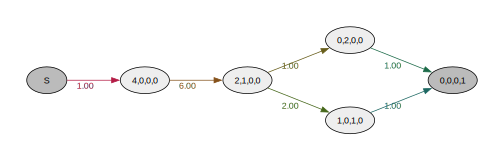

In [29]:
# Definer samme model som blev defineret i notebook 01
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    """Standard coalescent med en parameter (coalescence-rate = theta[0])."""
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

## 1. Method of Moments (MoM)

Method of Moments er en statistisk metode: jeg *matcher empiriske momenter* (gennemsnit, varians, osv.) fra data med de *teoretiske momenter* fra modellen. Den parameter-kombination, der giver den bedste match, er mit estimat.

Jeg simulerer her data fra en model med *sand theta = 7* og forsøger at genfinde den.

In [56]:
# Sæt sand parameter og simuler observationer
graph = Graph(coalescent_1param)

true_theta = [7]
graph.update_weights(true_theta)
observed_data = graph.sample(1000)

print(f"Simuleret: {len(observed_data)} observationer")
print(f"Empirisk gennemsnit: {np.mean(observed_data):.4f}")
print(f"Empirisk varians:    {np.var(observed_data):.4f}")


Simuleret: 1000 observationer
Empirisk gennemsnit: 0.2139
Empirisk varians:    0.0242


In [31]:
# Kør Method of Moments estimering
mom = graph.method_of_moments(observed_data)

print("=== Method of Moments Resultat ===")
print(f"Sand theta:     {true_theta}")
print(f"MoM estimat:    {mom.theta}")
print(f"Std. fejl:      {mom.std}")
print(f"Konvergeret:    {mom.success}")
print(f"Residual:       {mom.residual:.2e}")
print()
print("Sammenligning af momenter:")
print(f"  Empiriske:   {mom.sample_moments}")
print(f"  Model:       {mom.model_moments}")

[INFO] phasic.method_of_moments: theta_dim=1, n_free=1, nr_moments=3, n_features=1, n_equations=3
[INFO] phasic.method_of_moments: sample moments =
[[0.21505679 0.06984201 0.0313486 ]]
[INFO] phasic.method_of_moments: initial guess (full theta) = [6.95192796]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `ftol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [6.97951907]
[INFO] phasic.method_of_moments: residual = 4.357310e-01
[INFO] phasic.method_of_moments: model moments =
[0.21491452 0.06956749 0.03112762]


=== Method of Moments Resultat ===
Sand theta:     [7]
MoM estimat:    [6.97951907]
Std. fejl:      [0.04923617]
Konvergeret:    True
Residual:       4.36e-01

Sammenligning af momenter:
  Empiriske:   [[0.21505679 0.06984201 0.0313486 ]]
  Model:       [0.21491452 0.06956749 0.03112762]


## 2. Bayesiansk inferens med SVGD

MoM giver os et tal. Men i genetik er usikkerhed afgørende og jeg ønsker at vide: hvad er sandsynlighedsfordelingen over mulige parameterværdier givet data?. Dette er den *posterior-fordeling* i Bayesiansk statistik.

Phasic bruger **SVGD** (*Stein Variational Gradient Descent*): en algoritme der iterativt bevæger en sværm af "partikler" (kandidatparametre) mod den sande posterior ved hjælp af gradientinformation. Det er en alternativ til MCMC, der er bedre egnet til hurtig, differentiabel inferens.

**Prior-fordelingen** udtrykker vores viden *før* data. Her bruger jeg et bredt prior, der afspejler stor usikkerhed om theta.

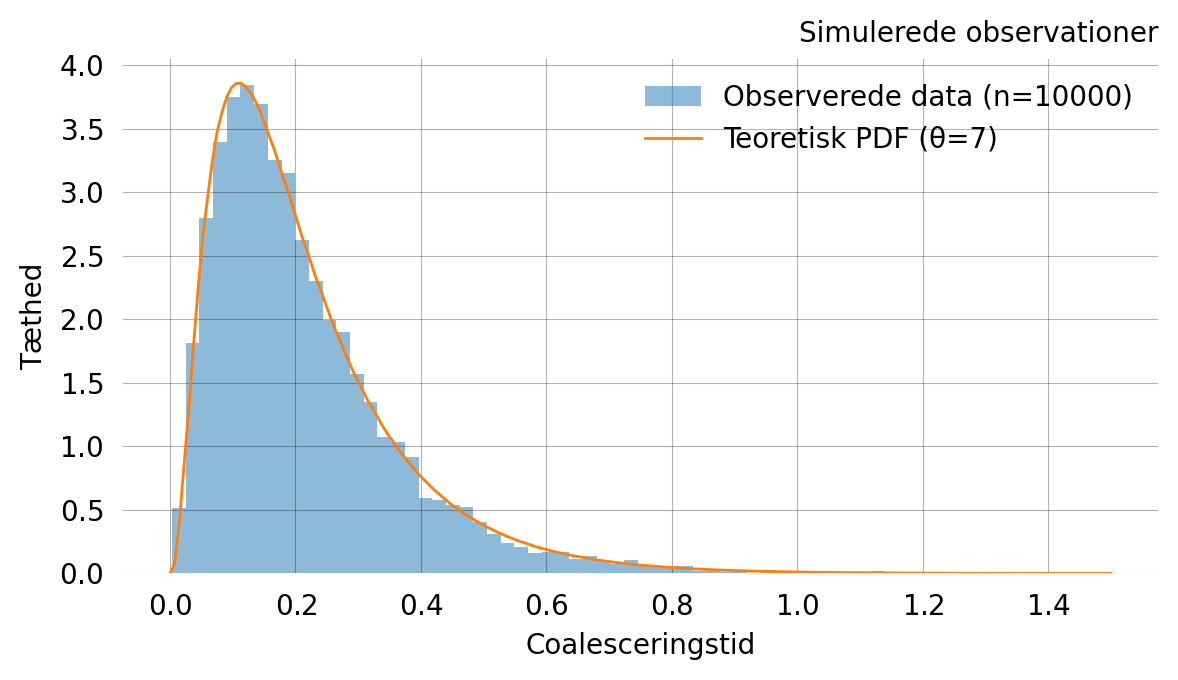

In [32]:
# Simuler et større datasæt for mere præcis estimering
nr_observations = 10000
graph.update_weights(true_theta)
observed_data = graph.sample(nr_observations)

# Visualiser data mod den teoretiske PDF
x = np.linspace(0, 1.5, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(observed_data, density=True, bins=60, alpha=0.5, 
        label=f'Observerede data (n={nr_observations})', color='C0')
ax.plot(x, graph.pdf(x), color='C1', lw=1, label=f'Teoretisk PDF (θ={true_theta[0]})')
ax.set_xlabel("Coalesceringstid")
ax.set_ylabel("Tæthed")
ax.set_title("Simulerede observationer")
ax.legend()
plt.tight_layout()
plt.show()


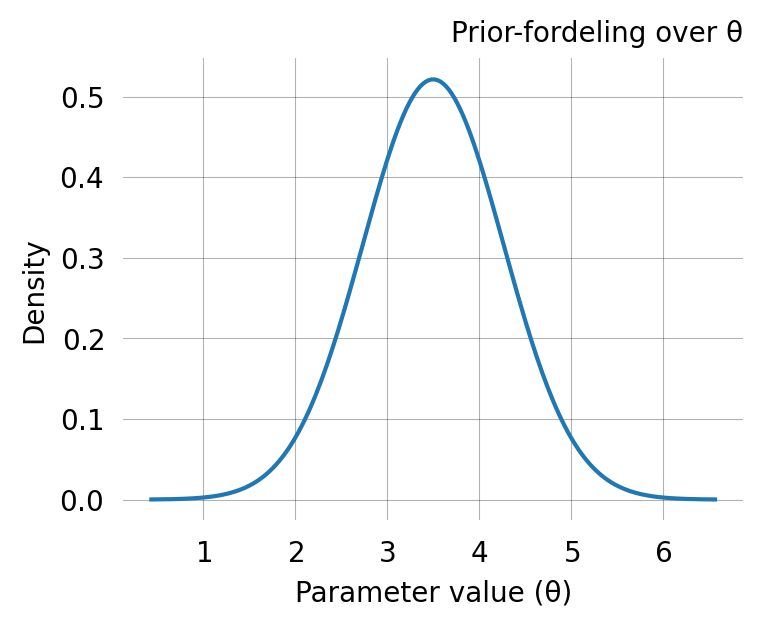

In [36]:
# Definer et bredt prior (stor usikkerhed om parameterværdien)
prior = GaussPrior(ci=[2, 5])
prior.plot()
plt.title("Prior-fordeling over θ")
plt.show()

In [39]:
# Kør SVGD-inferens
# step_schedule: learning rate falder eksponentielt, starter bredt og præciserer
step_schedule = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)

svgd = graph.svgd(
    observed_data,
    prior=prior,
    learning_rate=step_schedule,
    n_devices=1,       
)

print("SVGD Inferens Resultat")
print(f"Sand theta: {true_theta}")
svgd.summary()

SVGD Inferens Resultat
Sand theta: [7]
Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.0451     7.0537     0.0368     7.0055       7.1309      

Particles: 20, Iterations: 100


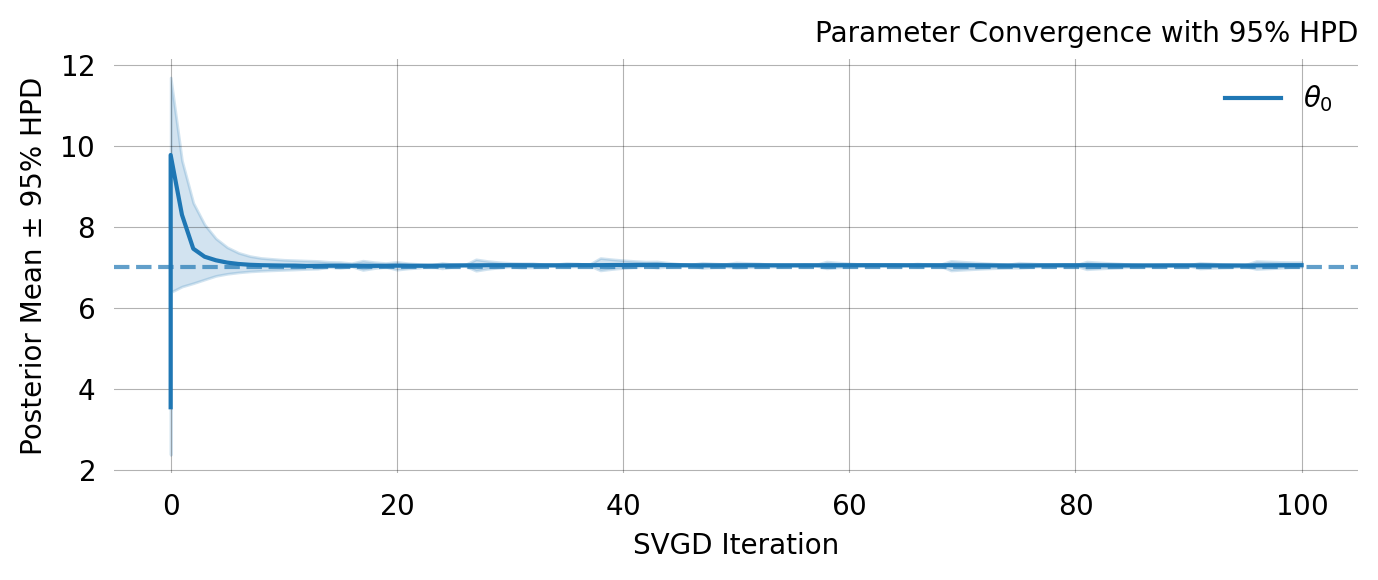

In [42]:
# Visualiser posterior med konfidensinterval og sand parameter
# Den blå region er 95% konfidensinterval for theta
svgd.plot_ci(true_theta=true_theta)

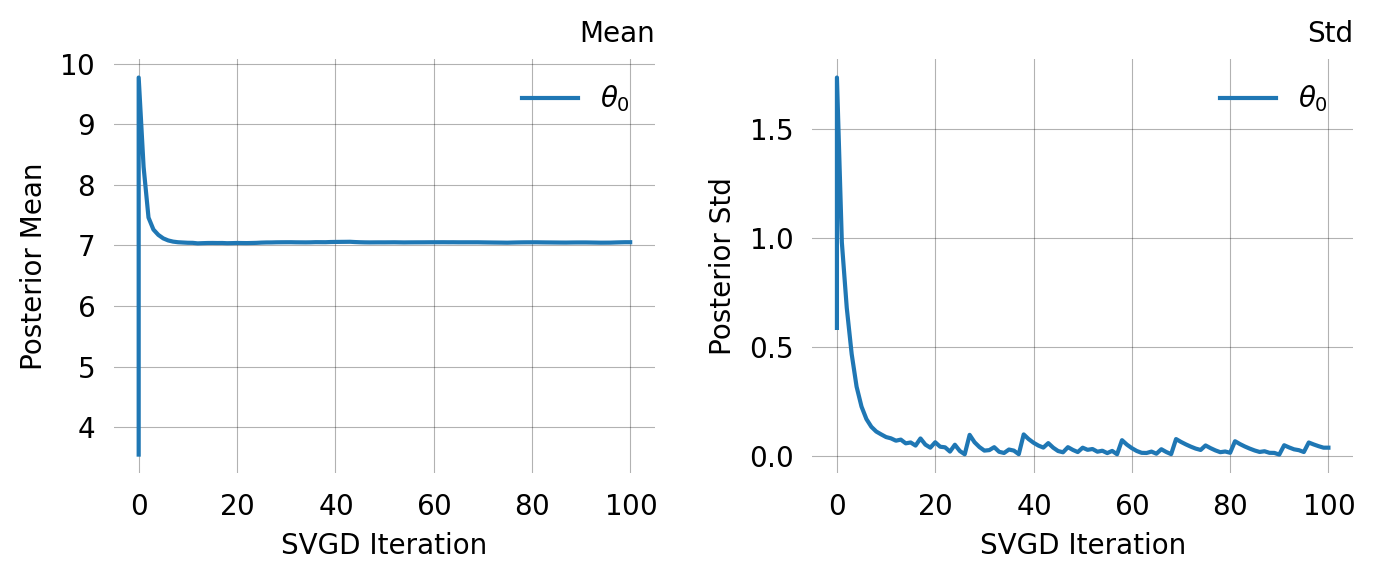

In [43]:
# Konvergensplot: er partiklerne stoppet med at bevæge sig?
# Fladende kurve = god konvergens
svgd.plot_convergence()
plt.show()

### Posterior Predictive Check

En god model kan *gengive de observerede data*. Jeg tjekker dette ved at sætte parametrene til posterior-gennemsnittet og sammenligne den modelbaserede PDF/CDF med de empiriske data. Tæt match = modellen forklarer data godt.

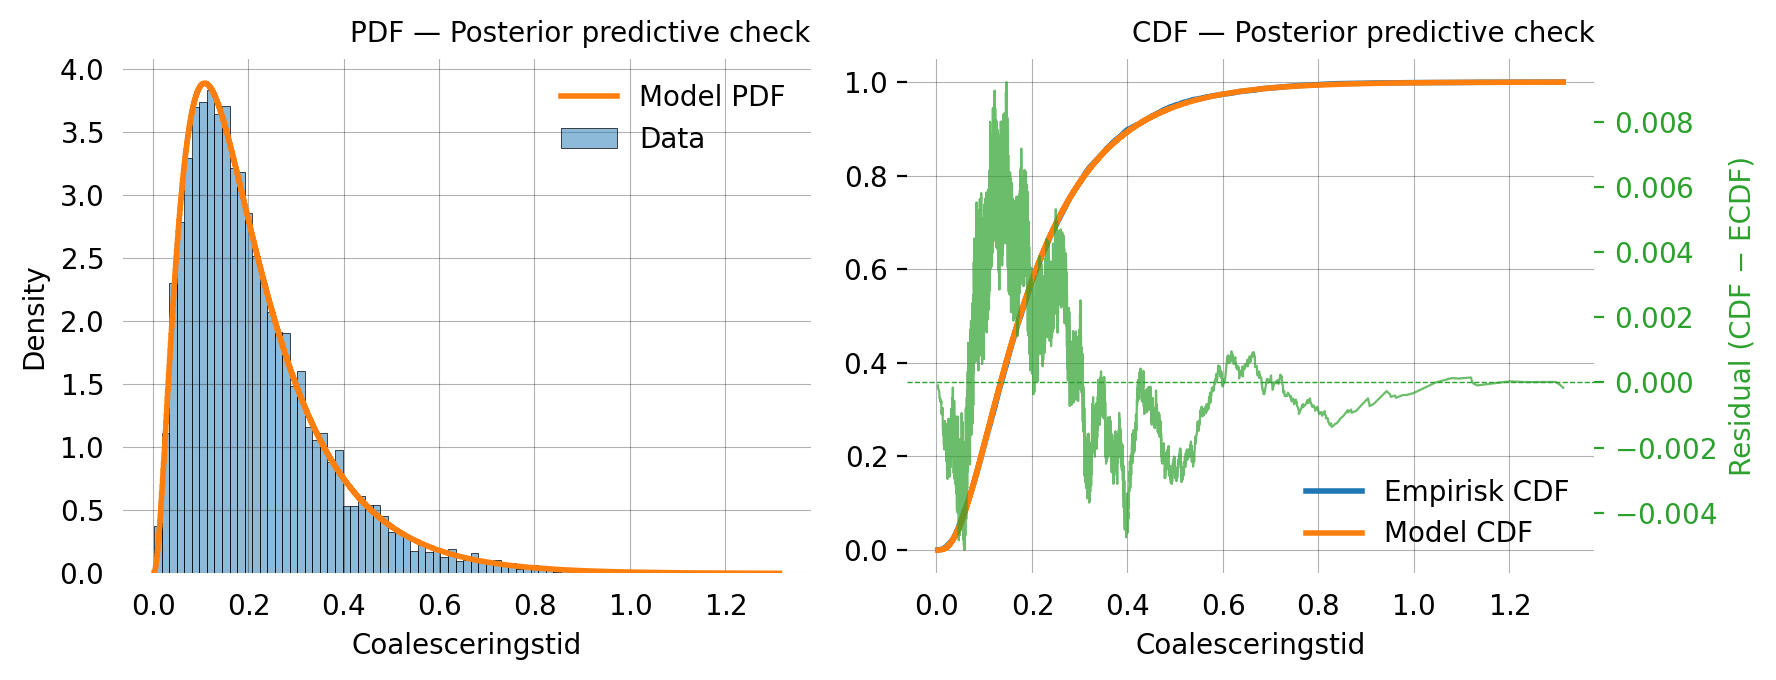

In [45]:
from scipy.stats import ecdf

res = ecdf(observed_data)
x_ecdf, ecdf_vals = res.cdf.quantiles, res.cdf.probabilities

# Opdater grafen med posterior-gennemsnittet
graph.update_weights(svgd.get_results()['theta_mean'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# PDF vs. histogram
sns.histplot(observed_data, kde=False, stat='density', label='Data', ax=ax1, alpha=0.5)
ax1.plot(x_ecdf, graph.pdf(x_ecdf), lw=2, c='C1', label='Model PDF')
ax1.set_xlabel('Coalesceringstid')
ax1.set_title('PDF — Posterior predictive check')
ax1.legend()

# CDF vs. empirisk CDF
ax2.plot(x_ecdf, ecdf_vals, lw=2, c='C0', label='Empirisk CDF')
ax2.plot(x_ecdf, graph.cdf(x_ecdf), lw=2, c='C1', label='Model CDF')
ax2.set_xlabel('Coalesceringstid')
ax2.set_title('CDF — Posterior predictive check')
ax2.legend()

# Residualplot (højre akse)
ax3 = ax2.twinx()
ax3.plot(x_ecdf, graph.cdf(x_ecdf) - ecdf_vals, lw=0.8, c='C2', alpha=0.7, label='CDF - ECDF')
ax3.axhline(0, ls='--', color='C2', lw=0.5)
ax3.set_ylabel('Residual (CDF − ECDF)', color='C2')
ax3.tick_params(axis='y', colors='C2')
ax3.grid(False)

plt.tight_layout()
plt.show()


## 3. To-populations model med migration

### Fra en til to populationer

Den simple coalescent antager en homogen population. For bavianerne er det ikke realistisk, der er flere geografisk adskilte grupper med potentiel migration imellem.

**To-ø modellen** (*island model*) tilføjer to processer:

1. **Coalescence** inden for hver population (rate 1/$N_e$)
2. **Migration** mellem populationer (rate migrationrate $m$)

State-vektoren udvides nu til at indeholde information om:

- Hvilke populationers efterkommere en lineage bærer (`pop1`, `pop2`)
- I hvilken population lineagen befinder sig (`in_pop`)

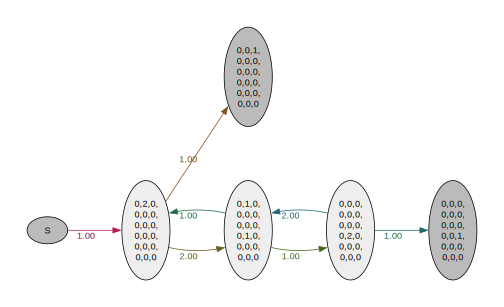

In [57]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

# Startstate: alle lineages er singletons fra population 1
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    """
    To-ø model med to parametre:
      theta[0] = coalescence-rate (1/N_e)
      theta[1] = migrationrate (m)
    """
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions

    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)

            # Coalescence kræver at begge lineages er i samme population
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                transitions.append([child, [state[i] * (state[j] - same) / (1 + same), 0]])

        # Migration: lineagen skifter population
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])

    return transitions

graph_2pop = Graph(two_island)
graph_2pop.plot()


In [58]:
# Sæt sande parametre og simuler data
true_theta = [0.7, 0.9]   # coalescence-rate, migrationrate
graph_2pop.update_weights(true_theta)
observations_2pop = graph_2pop.sample(1000)

print(f"To-populations model: {graph_2pop.param_length()} parametre")
print(f"  theta[0] = coalescence-rate = {true_theta[0]} (1/N_e)")
print(f"  theta[1] = migrationrate    = {true_theta[1]}")

# MoM estimering som udgangspunkt
mom_2pop = graph_2pop.method_of_moments(observations_2pop)

print("=== MoM estimat (to-populations model) ===")
print(f"Sand theta:    {true_theta}")
print(f"MoM estimat:   {mom_2pop.theta}")
print(f"Std. fejl:     {mom_2pop.std}")
print(f"Konvergeret:   {mom_2pop.success}")


[INFO] phasic.method_of_moments: theta_dim=2, n_free=2, nr_moments=2, n_features=1, n_equations=2
[INFO] phasic.method_of_moments: sample moments =
[[ 2.72446994 16.99189402]]


To-populations model: 2 parametre
  theta[0] = coalescence-rate = 0.7 (1/N_e)
  theta[1] = migrationrate    = 0.9


[INFO] phasic.method_of_moments: initial guess (full theta) = [ 0.6427516  27.24469944]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `gtol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [0.73408775 0.63465412]
[INFO] phasic.method_of_moments: residual = 3.076164e-29
[INFO] phasic.method_of_moments: model moments =
[ 2.72446994 16.99189402]


=== MoM estimat (to-populations model) ===
Sand theta:    [0.7, 0.9]
MoM estimat:   [0.73408775 0.63465412]
Std. fejl:     [0.0263706  0.19101926]
Konvergeret:   True


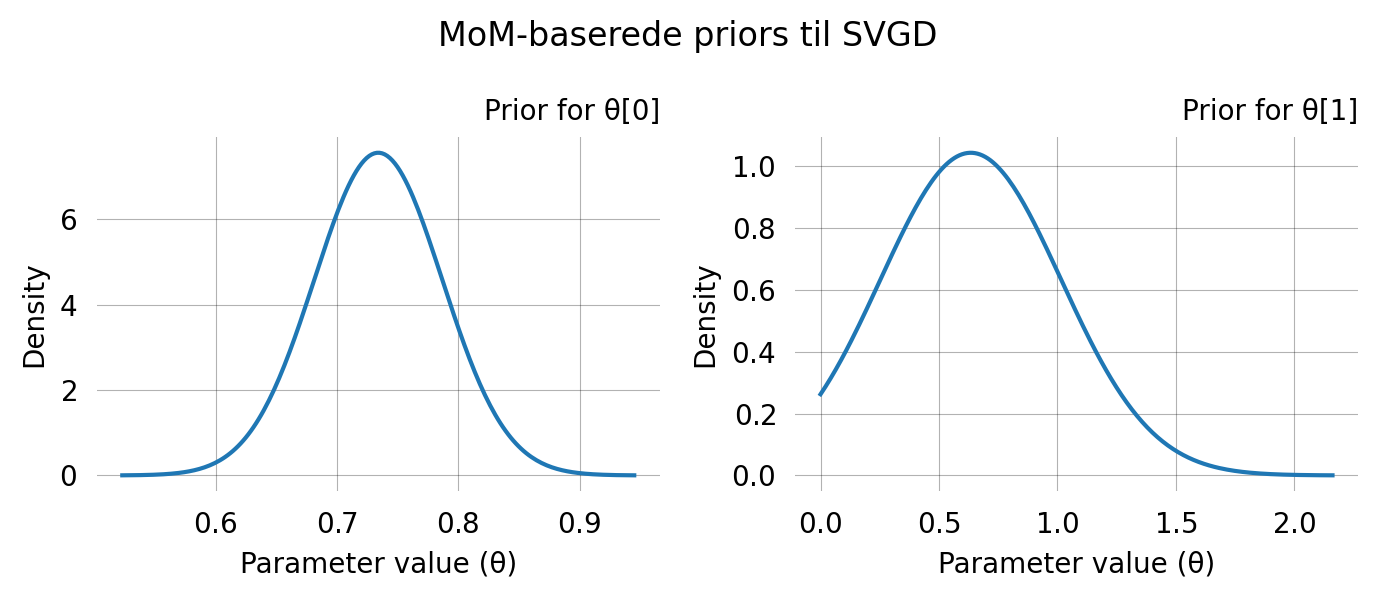

In [59]:
# SVGD med prior fra MoM-resultatet
# MoM giver automatisk et fornuftigt informeret prior
fig, axes = plt.subplots(1, len(mom_2pop.prior), figsize=(7, 3))
for i, prior in enumerate(mom_2pop.prior):
    prior.plot(return_ax=True, ax=axes[i])
    axes[i].set_title(f"Prior for θ[{i}]")
plt.suptitle("MoM-baserede priors til SVGD")
plt.tight_layout()
plt.show()

In [60]:
# Kør SVGD inferens på to-populations modellen
svgd_2pop = graph_2pop.svgd(
    observations_2pop,
    prior=mom_2pop.prior,
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=20.0),
    n_devices=1,
)

print("SVGD Resultat (to-populations model)")
svgd_2pop.summary()

SVGD Resultat (to-populations model)
Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.7317     0.7021     0.0921     0.4386       0.7672      
1          No         0.7202     0.6216     0.2225     0.0000       0.7385      

Particles: 40, Iterations: 100


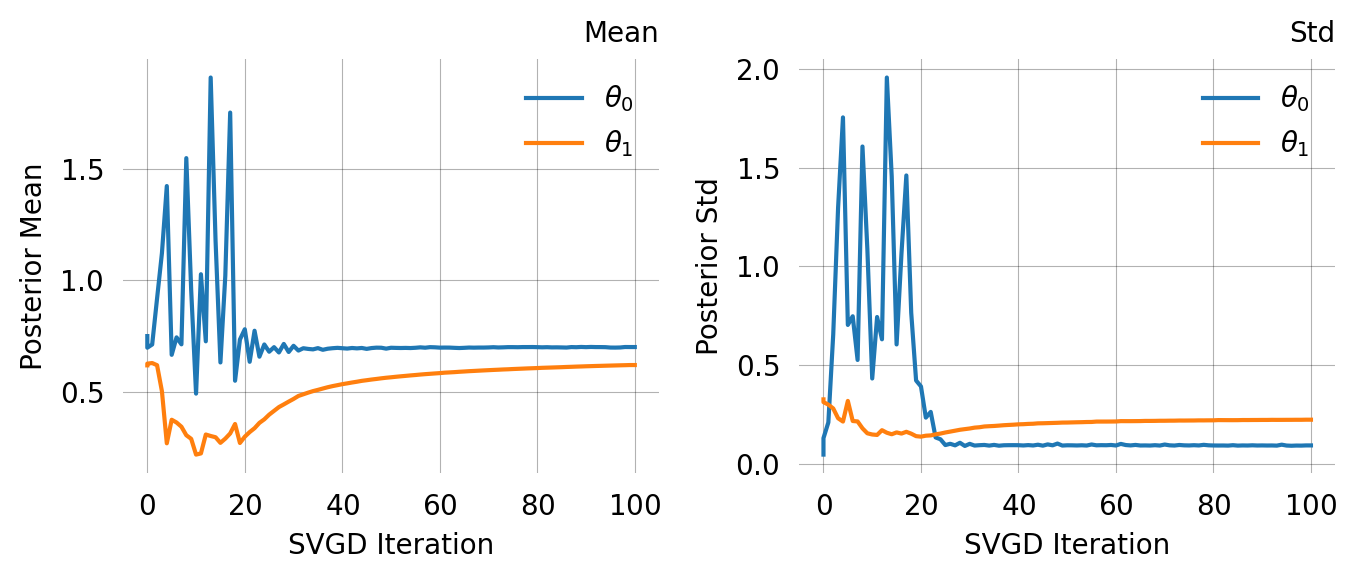

In [61]:
svgd_2pop.plot_convergence()

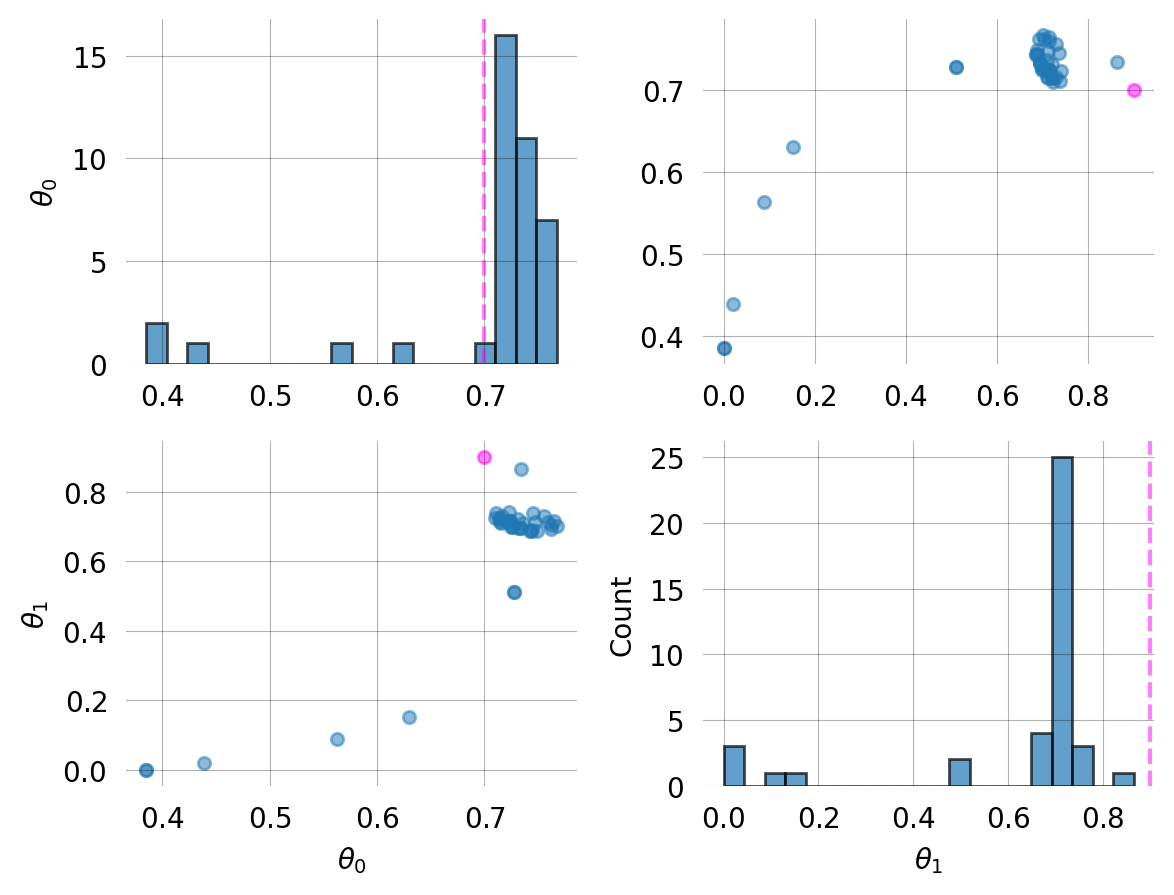

<Figure size 500x370 with 0 Axes>

In [62]:
# Pairwise posterior: viser fordelingen over begge parametre og korrelation imellem dem
# Korrelation mellem theta[0] og theta[1] er vigtig, det fortæller mig om parametrene er identifierbare fra data
svgd_2pop.plot_pairwise(true_theta=true_theta)
plt.suptitle("Posterior-fordeling: coalescence vs. migration", y=1.02)
plt.show()

## 4. Inferens med multiple observationstyper (rewards)

Frem for at bruge en statistik (fx gennemsnitlig coalesceringstid) kan jeg bruge *multiple features* samtidigt fx singleton, doubleton, tripleton. Disse er netop komponenterne i SFS'en fra Notebook 01.

Fordelen er, at jeg udnytter mere af informationen i data, og estimater bliver mere præcise. Dette er relevant for bavian-data, hvor jeg kan udtrække hele SFS som observationsvektor.

In [63]:
# Genbyg en-parameters model
graph_1p = Graph(coalescent_1param)
true_theta_1p = [7]
graph_1p.update_weights(true_theta_1p)

# Reward-matrix: én feature per lineage-type (singleton, doubleton, tripleton)
states = graph_1p.states().T
rewards = states[:-1]   # udelad den absorberende tilstand

print(f"Reward-matrixens form: {rewards.shape}")
print(f"  → {rewards.shape[0]} features (lineage-typer) × {rewards.shape[1]} state")

# Simuler data for hver feature separat
n_obs = 10000
n_features = rewards.shape[0]
observed_data_2d = np.zeros((n_obs * n_features, n_features), dtype=float)
observed_data_2d[:] = np.nan
for i in range(n_features):
    observed_data_2d[(i * n_obs):((i + 1) * n_obs), i] = graph_1p.sample(n_obs, rewards=rewards[i])

sparse_data = dense_to_sparse(observed_data_2d)
print(f"\nSamlet datasæt: {n_obs} observationer × {n_features} features")


Reward-matrixens form: (3, 6)
  → 3 features (lineage-typer) × 6 state

Samlet datasæt: 10000 observationer × 3 features


In [66]:
# MoM med multiple features
# Matcher nu momenter for alle 3 lineage-typer simultant
mom_multi = graph_1p.method_of_moments(sparse_data, rewards=rewards)

print(f"True theta:     {true_theta_1p}")
print(f"MoM estimate:   {mom_multi.theta}")
print(f"Converged:      {mom_multi.success}")
print(f"\nSample moments (n_features x nr_moments):\n{mom_multi.sample_moments}")
print(f"\nModel moments (n_features x nr_moments):\n{mom_multi.model_moments}")

[INFO] phasic.method_of_moments: theta_dim=1, n_free=1, nr_moments=2, n_features=3, n_equations=6
[INFO] phasic.method_of_moments: sample moments =
[[0.28632062 0.1178513 ]
 [0.14237024 0.06593977]
 [0.09529599 0.02733279]]


[INFO] phasic.method_of_moments: initial guess (full theta) = [6.95192796]
[INFO] phasic.method_of_moments: weighted GMM step 2 (cholesky): converged
[INFO] phasic.method_of_moments: converged — `ftol` termination condition is satisfied.
[INFO] phasic.method_of_moments: theta = [6.99282277]
[INFO] phasic.method_of_moments: residual = 3.359106e+00
[INFO] phasic.method_of_moments: model moments =
[[0.28600753 0.118156  ]
 [0.14300377 0.06816692]
 [0.09533584 0.02726677]]


True theta:     [7]
MoM estimate:   [6.99282277]
Converged:      True

Sample moments (n_features x nr_moments):
[[0.28632062 0.1178513 ]
 [0.14237024 0.06593977]
 [0.09529599 0.02733279]]

Model moments (n_features x nr_moments):
[[0.28600753 0.118156  ]
 [0.14300377 0.06816692]
 [0.09533584 0.02726677]]


## 5. Joint probability inferens med mutationsdata

I rigtige genomdata observerer jeg ikke coalesceringstider direkte. Man observerer antal mutationer fx antal SNPs der deles af præcis $k$ individer. Dette er diskrete tælledata. Joint probability-grafen kobler coalescent-teorien til mutationsmodellen og giver mig sandsynligheden for at observere et bestemt mønster af mutationstal.

Modellen har nu to parametre:

- $\theta =$ coalescence-rate (proportional med $1/N_e$)
- $\mu =$ mutationsrate (fikseret, estimeres separat)

In [3]:
from functools import partial
from itertools import combinations_with_replacement

all_pairs = partial(combinations_with_replacement, r=2)

# Build the coalescent base graph
nr_samples = 3

indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

base_graph = Graph(coalescent_1param)

# Create joint probability graph
mutation_rate = 1.0
joint_graph = base_graph.joint_prob_graph(
    indexer, tot_reward_limit=2, mutation_rate=mutation_rate
)
joint_graph.joint_prob_table()

,descendants_1,descendants_2,descendants_3,prob
t_vertex_index,,,,
4,0,0,0,0.166667
8,1,0,0,0.138889
11,0,1,0,0.055556
13,2,0,0,0.043981
14,1,1,0,0.032407
15,0,2,0,0.009259


In [4]:
# Sæt sande parametre og vis joint probability-tabellen
true_theta = [7.0, mutation_rate]
joint_graph.update_weights(true_theta)

# Sample from the joint probability table
table = joint_graph.joint_prob_table()
p = table['prob'].to_numpy()
p = p / p.sum()
feature_cols = table.columns[:-1]

np.random.seed(42)
n_obs = 2000
sampled_rows = np.random.choice(len(table), size=n_obs, p=p)
observations = [tuple(int(x) for x in row) for row in table.iloc[sampled_rows][feature_cols].values]
print(f"Sampled {n_obs} observations, first 5: {observations[:5]}")


Sampled 2000 observations, first 5: [(0, 0, 0), (2, 0, 0), (1, 0, 0), (0, 0, 0), (0, 0, 0)]


In [6]:
#kører `probability_matching()` med fixed mutation rate:
pm = joint_graph.probability_matching(
    observations,
    fixed=[(1, mutation_rate)],
)

print(f"True theta:     {true_theta}")
print(f"PM estimate:    {pm.theta}")
print(f"Std error:      {pm.std}")
print(f"Converged:      {pm.success}")
print(f"Residual:       {pm.residual:.2e}")



ProbMatch: theta_dim=2, n_free=1, n_obs=2000, n_unique_obs=6
ProbMatch: initial guess (full theta) = [7.88046282 1.        ]
ProbMatch: converged — `gtol` termination condition is satisfied.
ProbMatch: theta = [7.00204262 1.        ]
ProbMatch: residual = 3.839769e-05
True theta:     [7.0, 1.0]
PM estimate:    [7.00204262 1.        ]
Std error:      [0.3560501 0.       ]
Converged:      True
Residual:       3.84e-05


In [7]:
import pandas as pd
pd.DataFrame({
    'vertex_index': pm.unique_indices,
    'empirical_prob': pm.empirical_probs,
    'model_prob': pm.model_probs,
})

,vertex_index,empirical_prob,model_prob
0,4,0.6935,0.694502
1,8,0.1590,0.163940
2,11,0.0785,0.077149
3,13,0.0310,0.029057
4,14,0.0295,0.026782
5,15,0.0085,0.008570


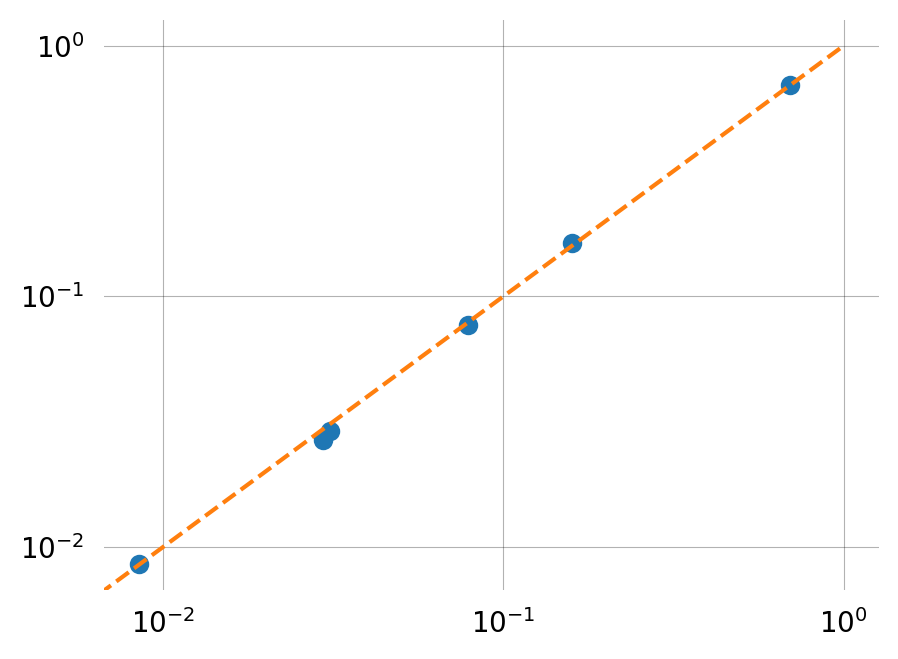

In [8]:
plt.plot([0, 1], [0, 1], ls='--', c='C1')
plt.scatter(pm.empirical_probs, pm.model_probs)
plt.xscale('log')
plt.yscale('log')

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.8942     6.8812     0.2086     6.6402       7.5867      
1          Yes        1.0000     NA         NA         NA           NA          

Particles: 40, Iterations: 100


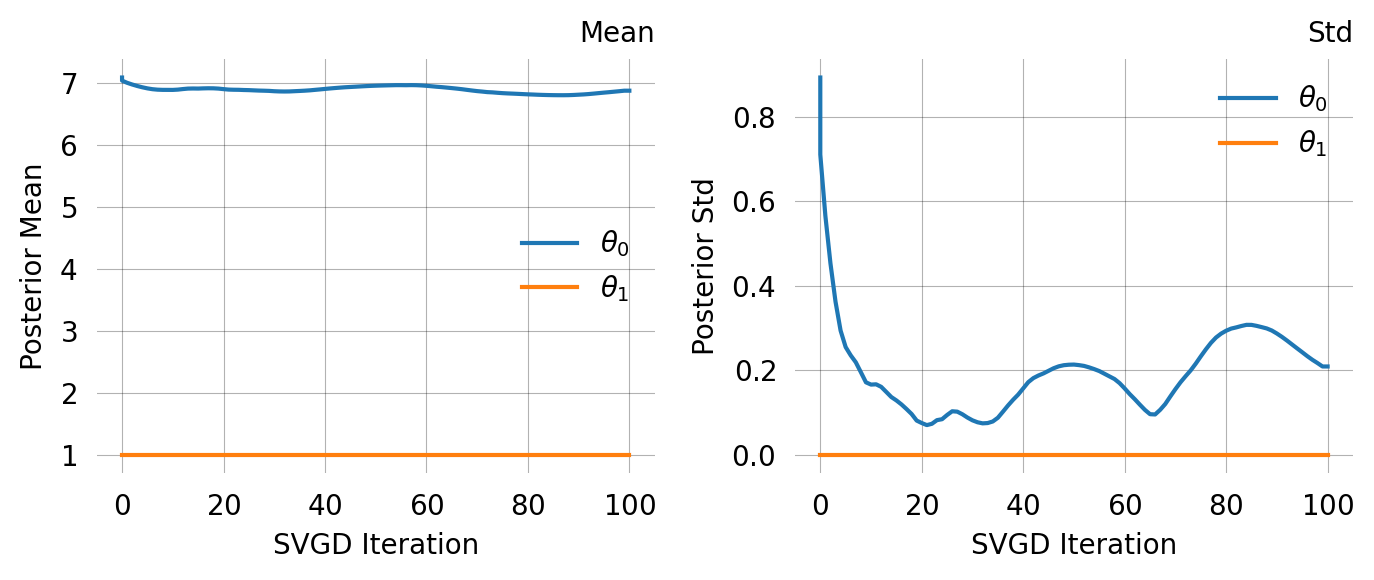

In [9]:
svgd_jp = joint_graph.svgd(
    observations,
    prior=pm.prior,
    fixed=[(1, mutation_rate)],
    optimizer=Adam(0.25),
)
svgd_jp.summary()
svgd_jp.plot_convergence()

## Opsummering

I denne notebook har jeg gennemgået de centrale inferens metoder, jeg vil anvende på bavian-data:

| Metode | Hvad den giver | Hvornår jeg bruger den |
|---|---|---|
| **Method of Moments** | Hurtigt punktestimat | Startsæt for SVGD, hurtig sanity check |
| **SVGD (enkelt parameter)** | Fuld posterior + usikkerhed | Enkel en-populations model |
| **SVGD (to parametre)** | Joint posterior, korrelationer | To-populations modeller med migration |
| **Multi-feature MoM** | Bedre estimater via SFS | Udnyt hele SFS, ikke kun gennemsnittet |
| **Joint probability SVGD** | Inferens fra tælledata | Direkte på genomdata med SNP-tæller |


I de næste notebooks, vil jeg nu arbejde med rigtige bavian-data.